# 02 — Análisis Exploratorio de Datos (EDA)

Este notebook analiza el dataset limpio del MDI 2019–2025 para entender:

- La estructura general del dataset
- Los patrones temporales del delito (año, mes, día, hora)
- Los patrones espaciales (distrito, circuito, subcircuito)
- Los tipos de delito más frecuentes
- Las variables de arma y lugar
- La calidad de los datos imputados vs. originales


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

In [2]:
# =========================
# RUTA DEL DATASET LIMPIO
# =========================
ARCHIVO = r"C:\Users\jhono\Downloads\Proyecto Titulación\CSV\mdi_detenidosaprehendidos_guayaquil_2019_2025_con_delitos_y_tipo_dato.csv"

## 1. Carga y vista general

In [3]:
# =========================
# CARGAR DATASET
# =========================
df = pd.read_csv(
    ARCHIVO,
    sep=";",
    encoding="utf-8-sig",
    keep_default_na=False,
    low_memory=False
)

# Convertir coordenadas a float (por si vienen como texto)
for col in ["latitud", "longitud"]:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(",", ".", regex=False),
        errors="coerce"
    )

# Convertir fecha
df["fecha_dt"] = pd.to_datetime(
    df["fecha_detencion_aprehension"], dayfirst=True, errors="coerce"
)
df["anio"]      = df["fecha_dt"].dt.year
df["mes"]       = df["fecha_dt"].dt.month
df["dia_semana"]= df["fecha_dt"].dt.dayofweek   # 0=lunes, 6=domingo
df["hora"]      = pd.to_numeric(
    df["hora_detencion_aprehension"].str.split(":").str[0], errors="coerce"
)

print(f"Filas    : {len(df):,}")
print(f"Columnas : {len(df.columns)}")
df.dtypes

Filas    : 76,860
Columnas : 44


Unnamed: 0                             object
codigo_iccs                           float64
delitos                                object
tipo_dato                              object
tipo                                   object
estado civil                           object
estatus_migratorio                     object
edad                                   object
sexo                                   object
genero                                 object
nacionalidad                           object
autoidentificacion_etnica              object
nivel_de_instruccion                   object
condicion                              object
movilizacion                           object
tipo_arma                              object
arma                                   object
fecha_detencion_aprehension            object
hora_detencion_aprehension             object
lugar                                  object
tipo_lugar                             object
nombre_zona                       

In [4]:
# =========================
# VALORES NULOS POR COLUMNA
# =========================
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
if len(nulos) == 0:
    print("Sin valores nulos en ninguna columna.")
else:
    print(nulos)

Sin valores nulos en ninguna columna.


In [5]:
# =========================
# CALIDAD DE DATOS: tipo_dato y flag_coord
# =========================
print("tipo_dato (codigo_iccs):")
print(df["tipo_dato"].value_counts())
print(f"  -> {df[df['tipo_dato']=='SINTETICO'].shape[0]/len(df)*100:.1f}% imputado por Random Forest\n")

print("flag_coord (latitud/longitud):")
print(df["flag_coord"].value_counts())
print(f"  -> {df[df['flag_coord']=='IMPUTADO'].shape[0]/len(df)*100:.1f}% imputado por centroide de subcircuito")

tipo_dato (codigo_iccs):
tipo_dato
ORIGINAL     56045
SINTETICO    20815
Name: count, dtype: int64
  -> 27.1% imputado por Random Forest

flag_coord (latitud/longitud):
flag_coord
IMPUTADO    67046
REAL         9814
Name: count, dtype: int64
  -> 87.2% imputado por centroide de subcircuito


## 2. Distribución temporal

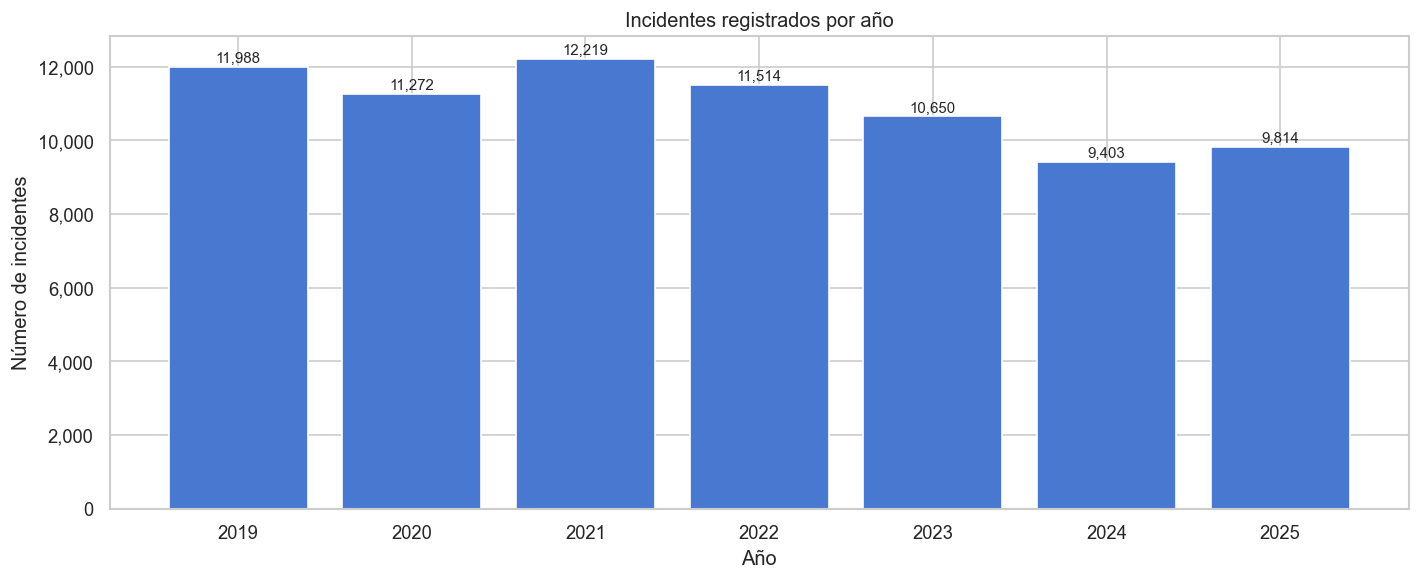

In [6]:
# =========================
# INCIDENTES POR AÑO
# =========================
por_anio = df.groupby("anio").size().reset_index(name="total")

fig, ax = plt.subplots()
ax.bar(por_anio["anio"], por_anio["total"], color=sns.color_palette("muted")[0])
ax.set_title("Incidentes registrados por año")
ax.set_xlabel("Año")
ax.set_ylabel("Número de incidentes")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar, val in zip(ax.patches, por_anio["total"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f"{val:,}", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

In [7]:
# =============================================================
# CONFIGURACIÓN GLOBAL — GRÁFICAS AGRUPADAS POR AÑO
# =============================================================
YEARS   = [2019, 2020, 2021, 2022, 2023, 2024, 2025]
COLORES = ['#1f77b4','#ff7f0e','#2ca02c','#d62728',
           '#9467bd','#8c564b','#e377c2']
PALETTE = dict(zip(YEARS, COLORES))

plt.rcParams.update({
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'grid.linestyle'   : '--',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'figure.dpi'       : 150,
})

def grafica_agrupada(pivot_df, titulo, xlabel, ylabel,
                     figsize=(16,7), rotation=0, fontsize_bar=7):
    categorias = pivot_df.index.tolist()
    n_cat  = len(categorias)
    n_anios = len(pivot_df.columns)
    ancho  = 0.8 / n_anios
    x      = np.arange(n_cat)

    fig, ax = plt.subplots(figsize=figsize)

    for i, year in enumerate(pivot_df.columns):
        valores = pivot_df[year].fillna(0).values
        offset  = (i - n_anios / 2 + 0.5) * ancho
        bars    = ax.bar(x + offset, valores, ancho,
                         label=str(year),
                         color=PALETTE.get(year, COLORES[i % len(COLORES)]),
                         alpha=0.88, edgecolor='white', linewidth=0.4)
        for bar, val in zip(bars, valores):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + max(valores) * 0.01,
                        f'{int(val):,}',
                        ha='center', va='bottom',
                        fontsize=fontsize_bar, rotation=90,
                        color='#333333')

    ax.set_title(titulo, fontsize=14, fontweight='bold', pad=14)
    ax.set_xlabel(xlabel, fontsize=11, labelpad=8)
    ax.set_ylabel(ylabel, fontsize=11, labelpad=8)
    ax.set_xticks(x)
    ax.set_xticklabels(categorias,
                       rotation=rotation,
                       ha='right' if rotation else 'center',
                       fontsize=10)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
    ax.legend(title='Año', bbox_to_anchor=(1.01, 1),
              loc='upper left', fontsize=9, title_fontsize=10)
    ax.margins(x=0.02)
    fig.tight_layout()
    plt.show()


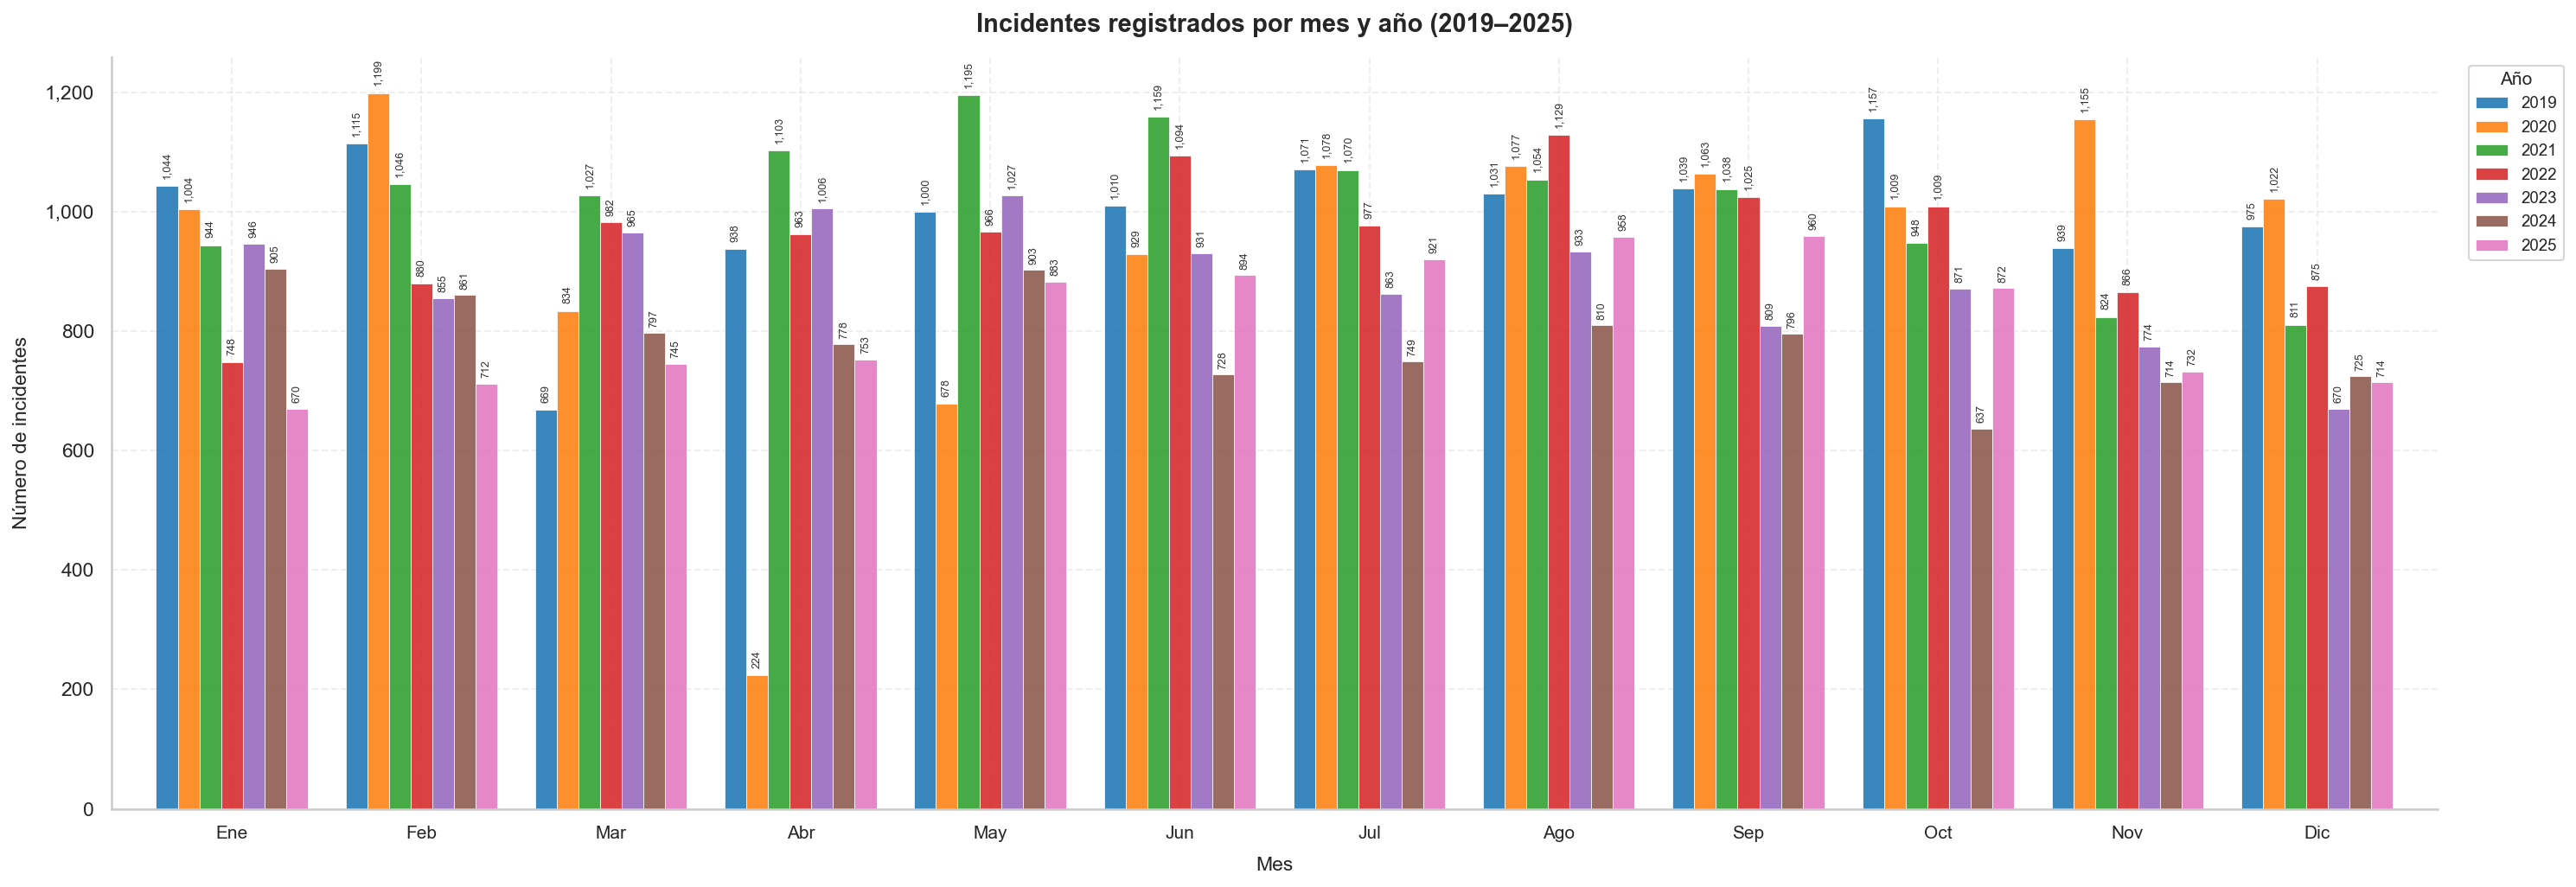

In [8]:
# =============================================================
# INCIDENTES POR MES Y AÑO (barras agrupadas)
# =============================================================
MESES = ['Ene','Feb','Mar','Abr','May','Jun',
         'Jul','Ago','Sep','Oct','Nov','Dic']

por_mes_anio = (
    df.groupby(['anio','mes'])
    .size()
    .reset_index(name='total')
)
por_mes_anio['mes_nombre'] = por_mes_anio['mes'].apply(lambda m: MESES[m-1])

pivot_mes = (
    por_mes_anio
    .pivot(index='mes_nombre', columns='anio', values='total')
    .reindex(MESES)
    [YEARS]
)

grafica_agrupada(
    pivot_mes,
    titulo       = 'Incidentes registrados por mes y año (2019–2025)',
    xlabel       = 'Mes',
    ylabel       = 'Número de incidentes',
    figsize      = (20, 7),
    fontsize_bar = 6,
)


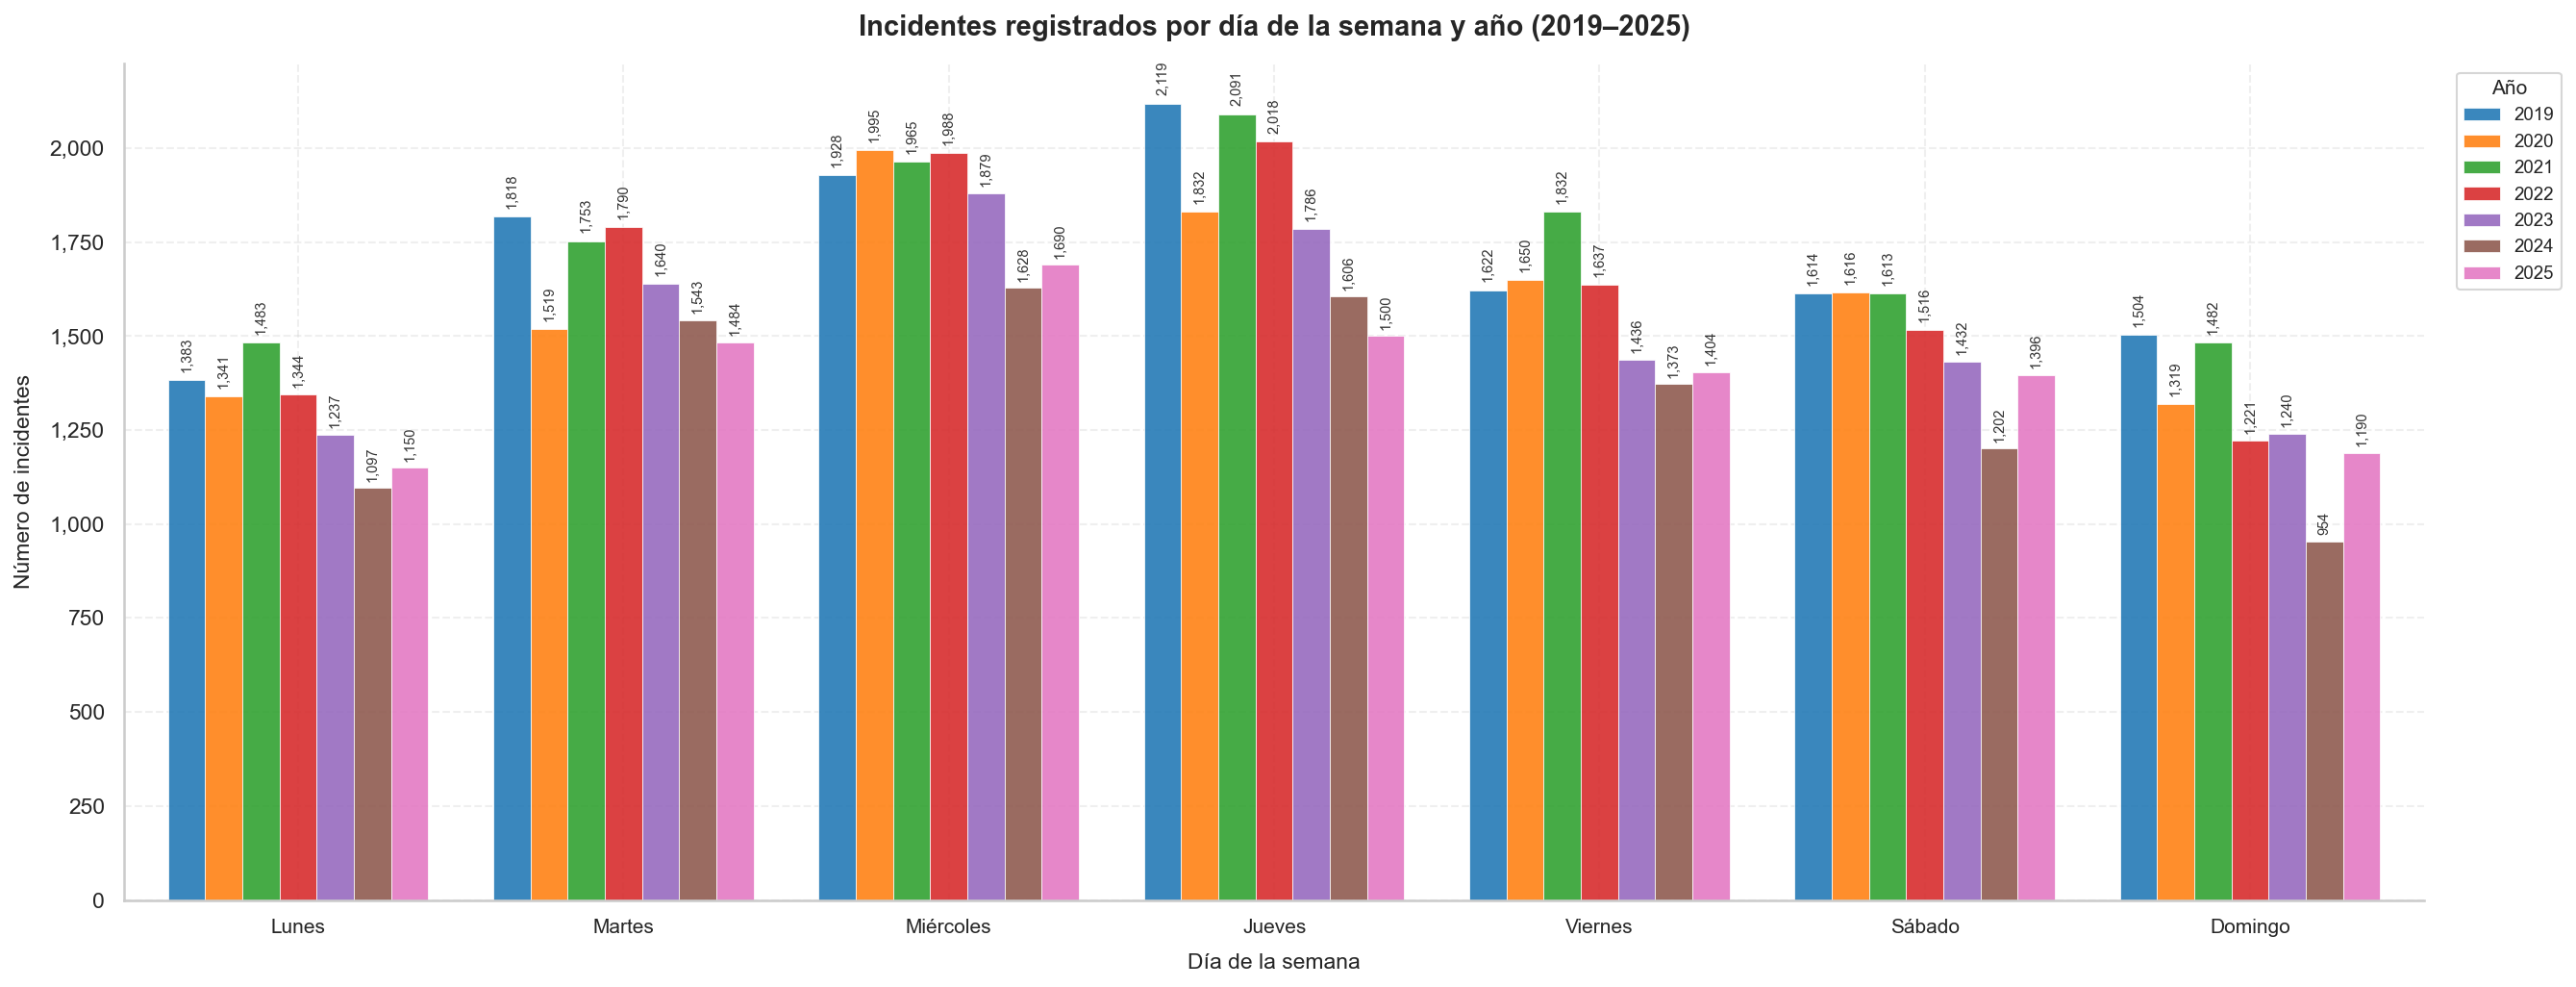

In [9]:
# =============================================================
# INCIDENTES POR DÍA DE LA SEMANA Y AÑO (barras agrupadas)
# =============================================================
DIAS = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']

por_dia_anio = (
    df.groupby(['anio','dia_semana'])
    .size()
    .reset_index(name='total')
)
por_dia_anio['dia_nombre'] = por_dia_anio['dia_semana'].apply(lambda d: DIAS[d])

pivot_dia = (
    por_dia_anio
    .pivot(index='dia_nombre', columns='anio', values='total')
    .reindex(DIAS)
    [YEARS]
)

grafica_agrupada(
    pivot_dia,
    titulo       = 'Incidentes registrados por día de la semana y año (2019–2025)',
    xlabel       = 'Día de la semana',
    ylabel       = 'Número de incidentes',
    figsize      = (18, 7),
    fontsize_bar = 7,
)


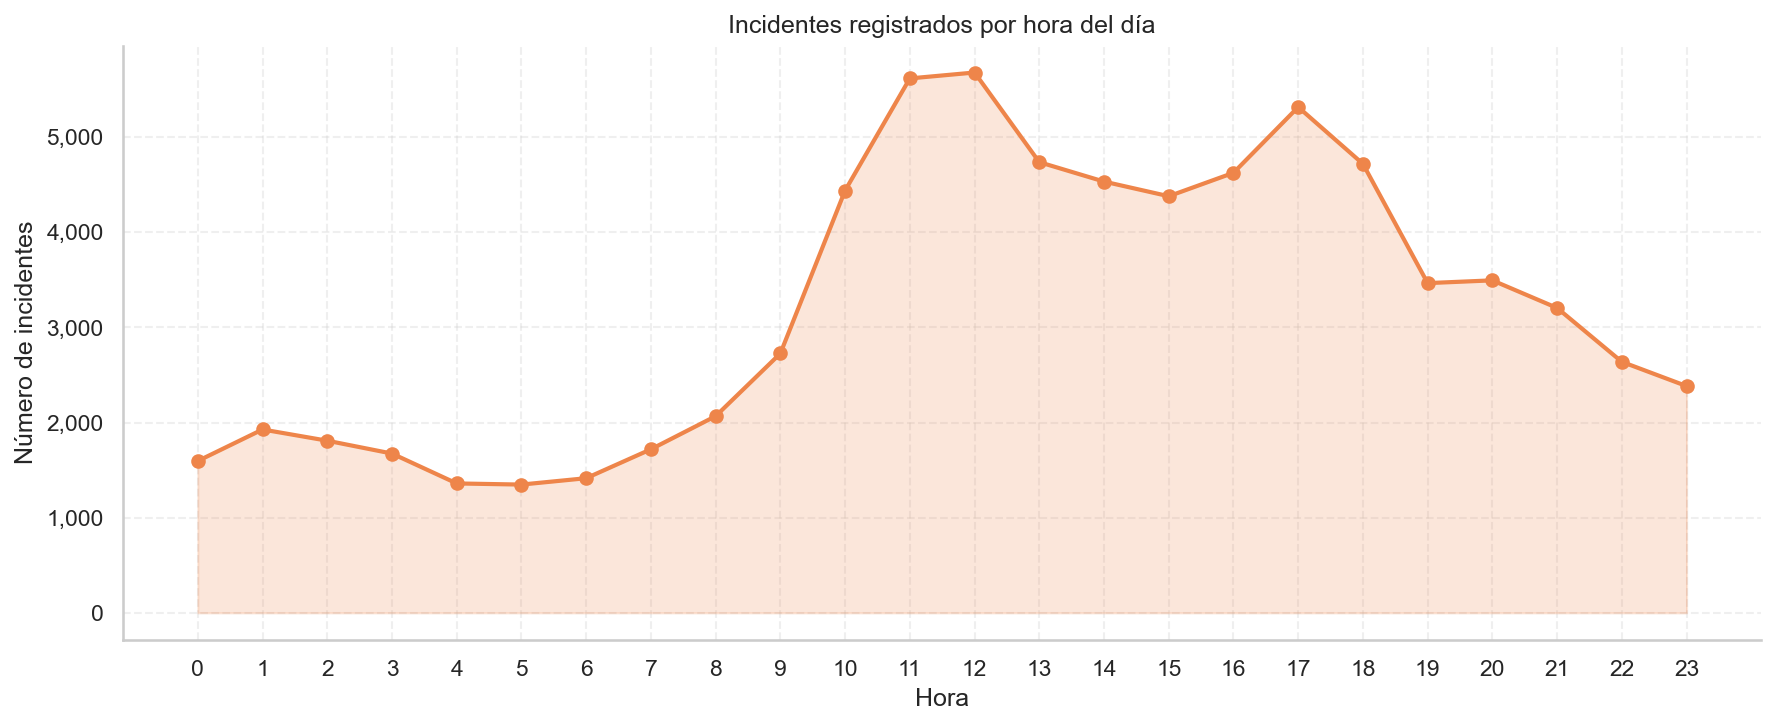

In [10]:
# =========================
# INCIDENTES POR HORA DEL DÍA
# =========================
por_hora = df.groupby("hora").size().reset_index(name="total")

fig, ax = plt.subplots()
ax.plot(por_hora["hora"], por_hora["total"], marker="o", linewidth=2,
        color=sns.color_palette("muted")[1])
ax.fill_between(por_hora["hora"], por_hora["total"], alpha=0.2,
                color=sns.color_palette("muted")[1])
ax.set_title("Incidentes registrados por hora del día")
ax.set_xlabel("Hora")
ax.set_ylabel("Número de incidentes")
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

## 3. Tipos de delito

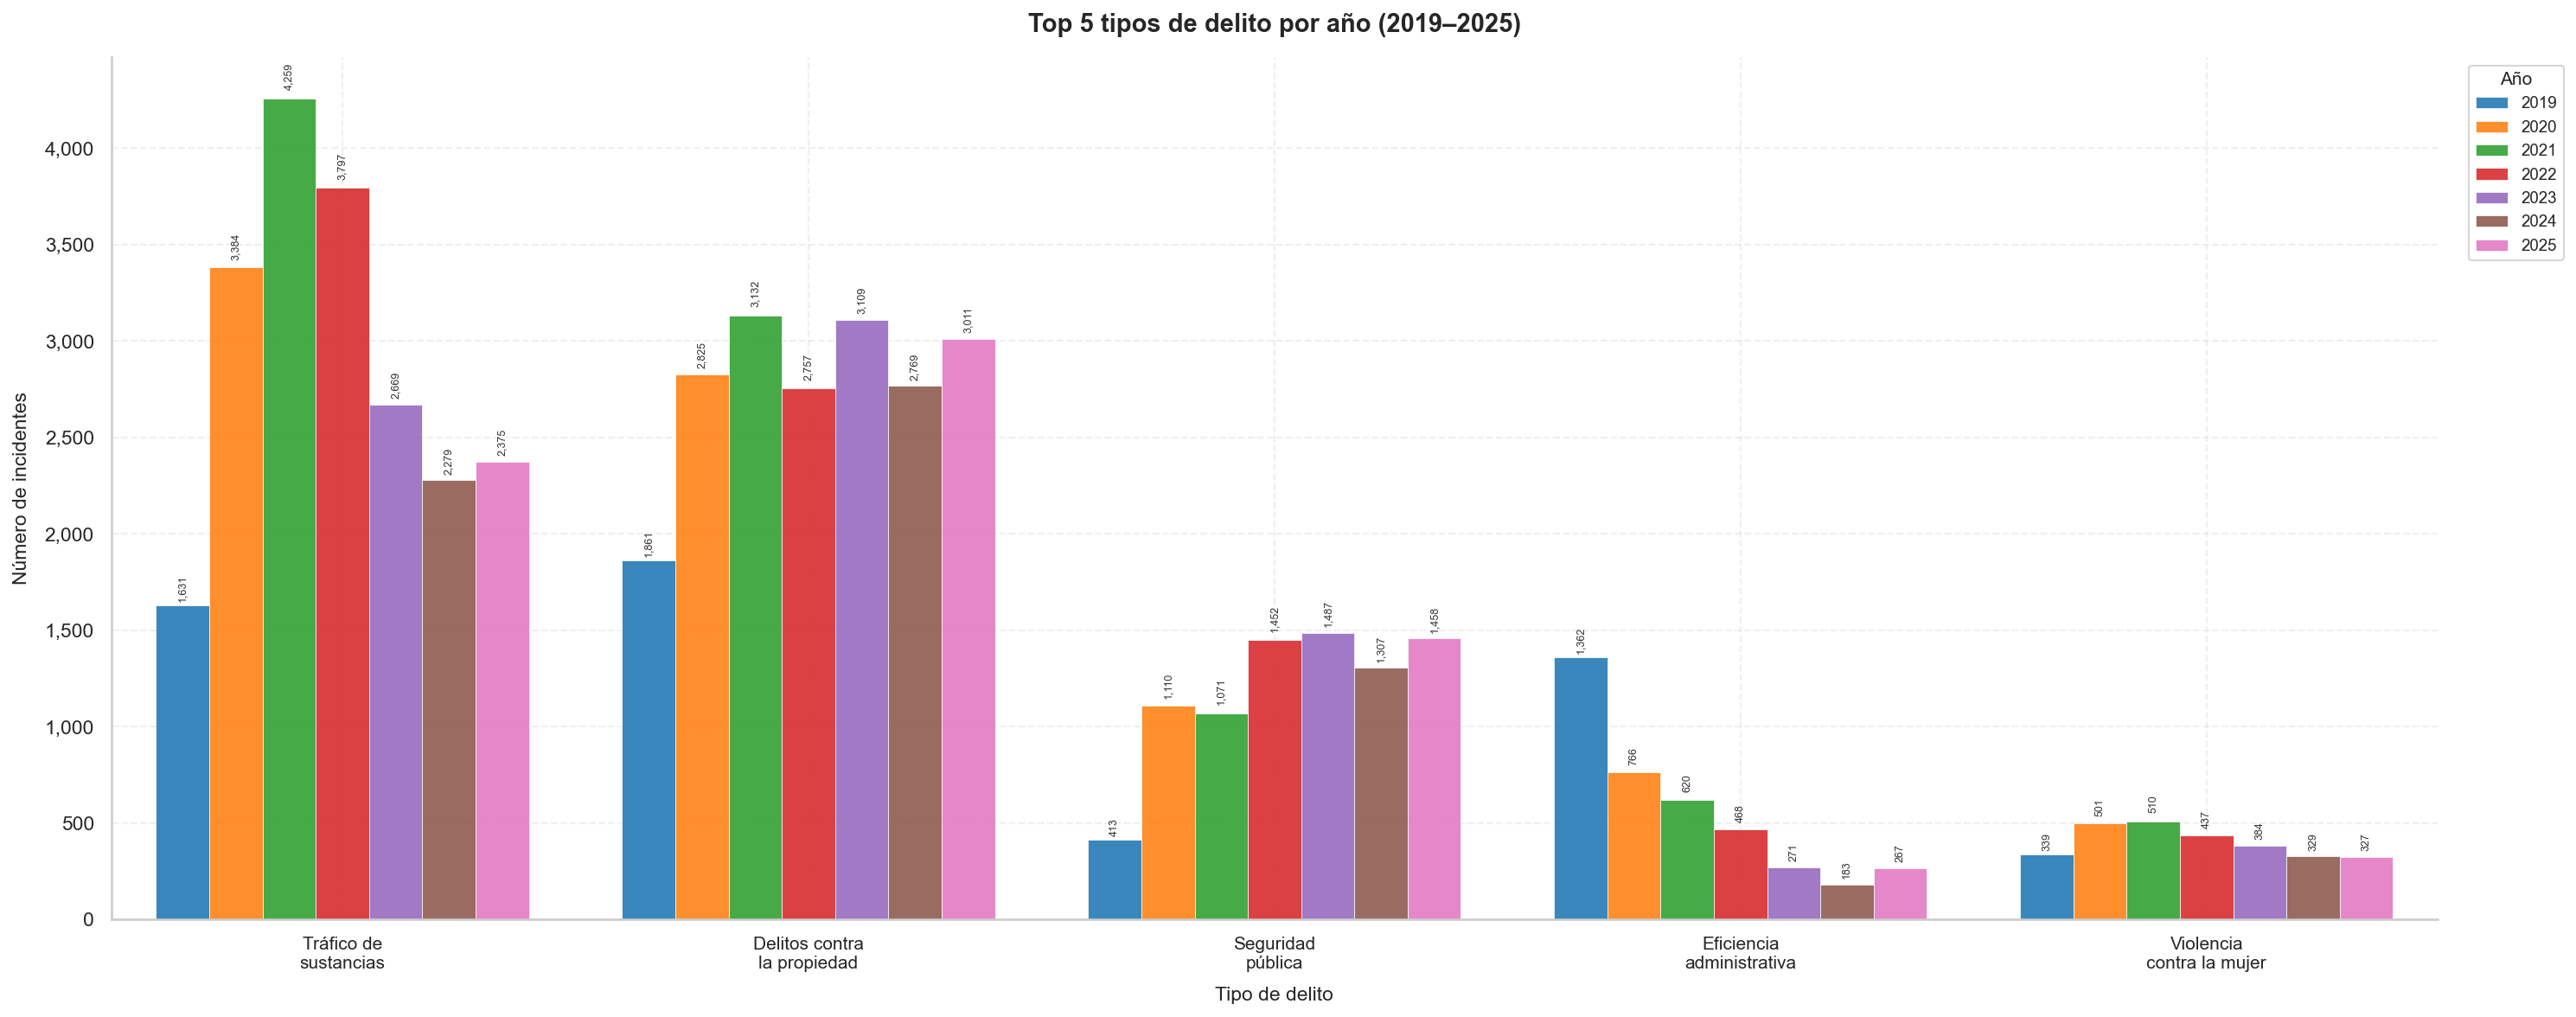

In [21]:
# =============================================================
# TOP 5 TIPOS DE DELITO POR AÑO (barras agrupadas)
# Etiquetas cortas definidas manualmente para legibilidad
# =============================================================
top5_delitos = df['delitos'].value_counts().head(5).index.tolist()

# Etiquetas cortas manuales (en orden del ranking)
ETIQUETAS_CORTAS = {
    top5_delitos[0]: 'Tráfico de\nsustancias',
    top5_delitos[1]: 'Delitos contra\nla propiedad',
    top5_delitos[2]: 'Seguridad\npública',
    top5_delitos[3]: 'Eficiencia\nadministrativa',
    top5_delitos[4]: 'Violencia\ncontra la mujer',
}

por_delito_anio = (
    df[df['delitos'].isin(top5_delitos)]
    .groupby(['anio','delitos'])
    .size()
    .reset_index(name='total')
)

por_delito_anio['delito_corto'] = por_delito_anio['delitos'].map(ETIQUETAS_CORTAS)
orden_etiquetas = [ETIQUETAS_CORTAS[d] for d in top5_delitos]

pivot_delito = (
    por_delito_anio
    .pivot(index='delito_corto', columns='anio', values='total')
    .reindex(orden_etiquetas)
    [YEARS]
)

grafica_agrupada(
    pivot_delito,
    titulo       = 'Top 5 tipos de delito por año (2019–2025)',
    xlabel       = 'Tipo de delito',
    ylabel       = 'Número de incidentes',
    figsize      = (20, 8),
    rotation     = 0,        # horizontal — etiquetas multi-línea no necesitan rotación
    fontsize_bar = 6,
)


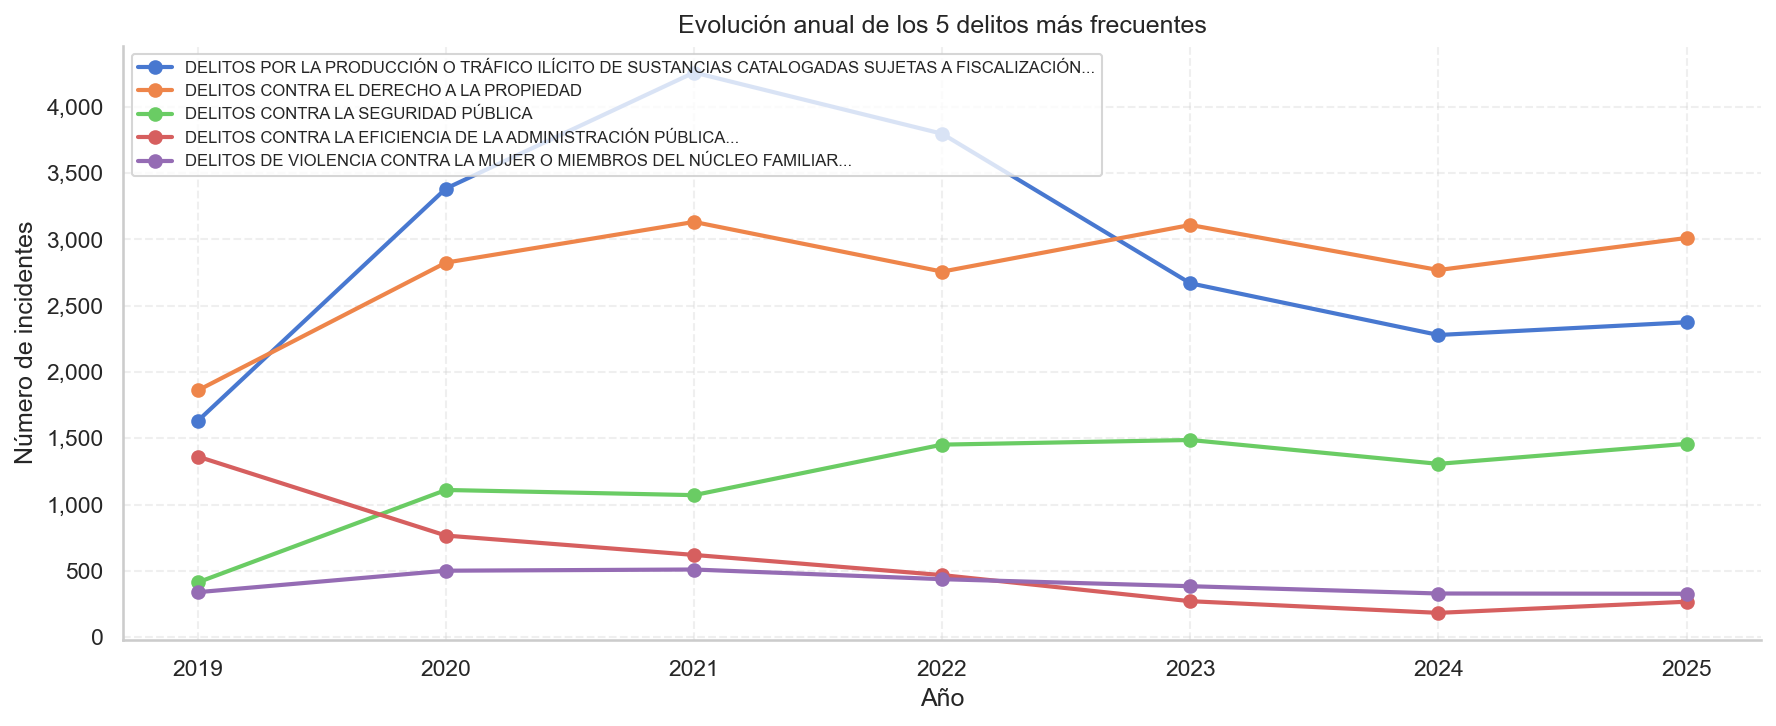

In [12]:
# =========================
# EVOLUCIÓN TEMPORAL DE LOS TOP 5 DELITOS
# =========================
top5 = df["delitos"].value_counts().head(5).index.tolist()

evolucion = (
    df[df["delitos"].isin(top5)]
    .groupby(["anio", "delitos"])
    .size()
    .reset_index(name="total")
)

fig, ax = plt.subplots(figsize=(12, 5))
for delito in top5:
    datos = evolucion[evolucion["delitos"] == delito]
    etiqueta = delito[:100] + "..." if len(delito) > 40 else delito
    ax.plot(datos["anio"], datos["total"], marker="o", label=etiqueta, linewidth=2)

ax.set_title("Evolución anual de los 5 delitos más frecuentes")
ax.set_xlabel("Año")
ax.set_ylabel("Número de incidentes")
ax.legend(fontsize=8, loc="upper left")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

## 4. Distribución espacial

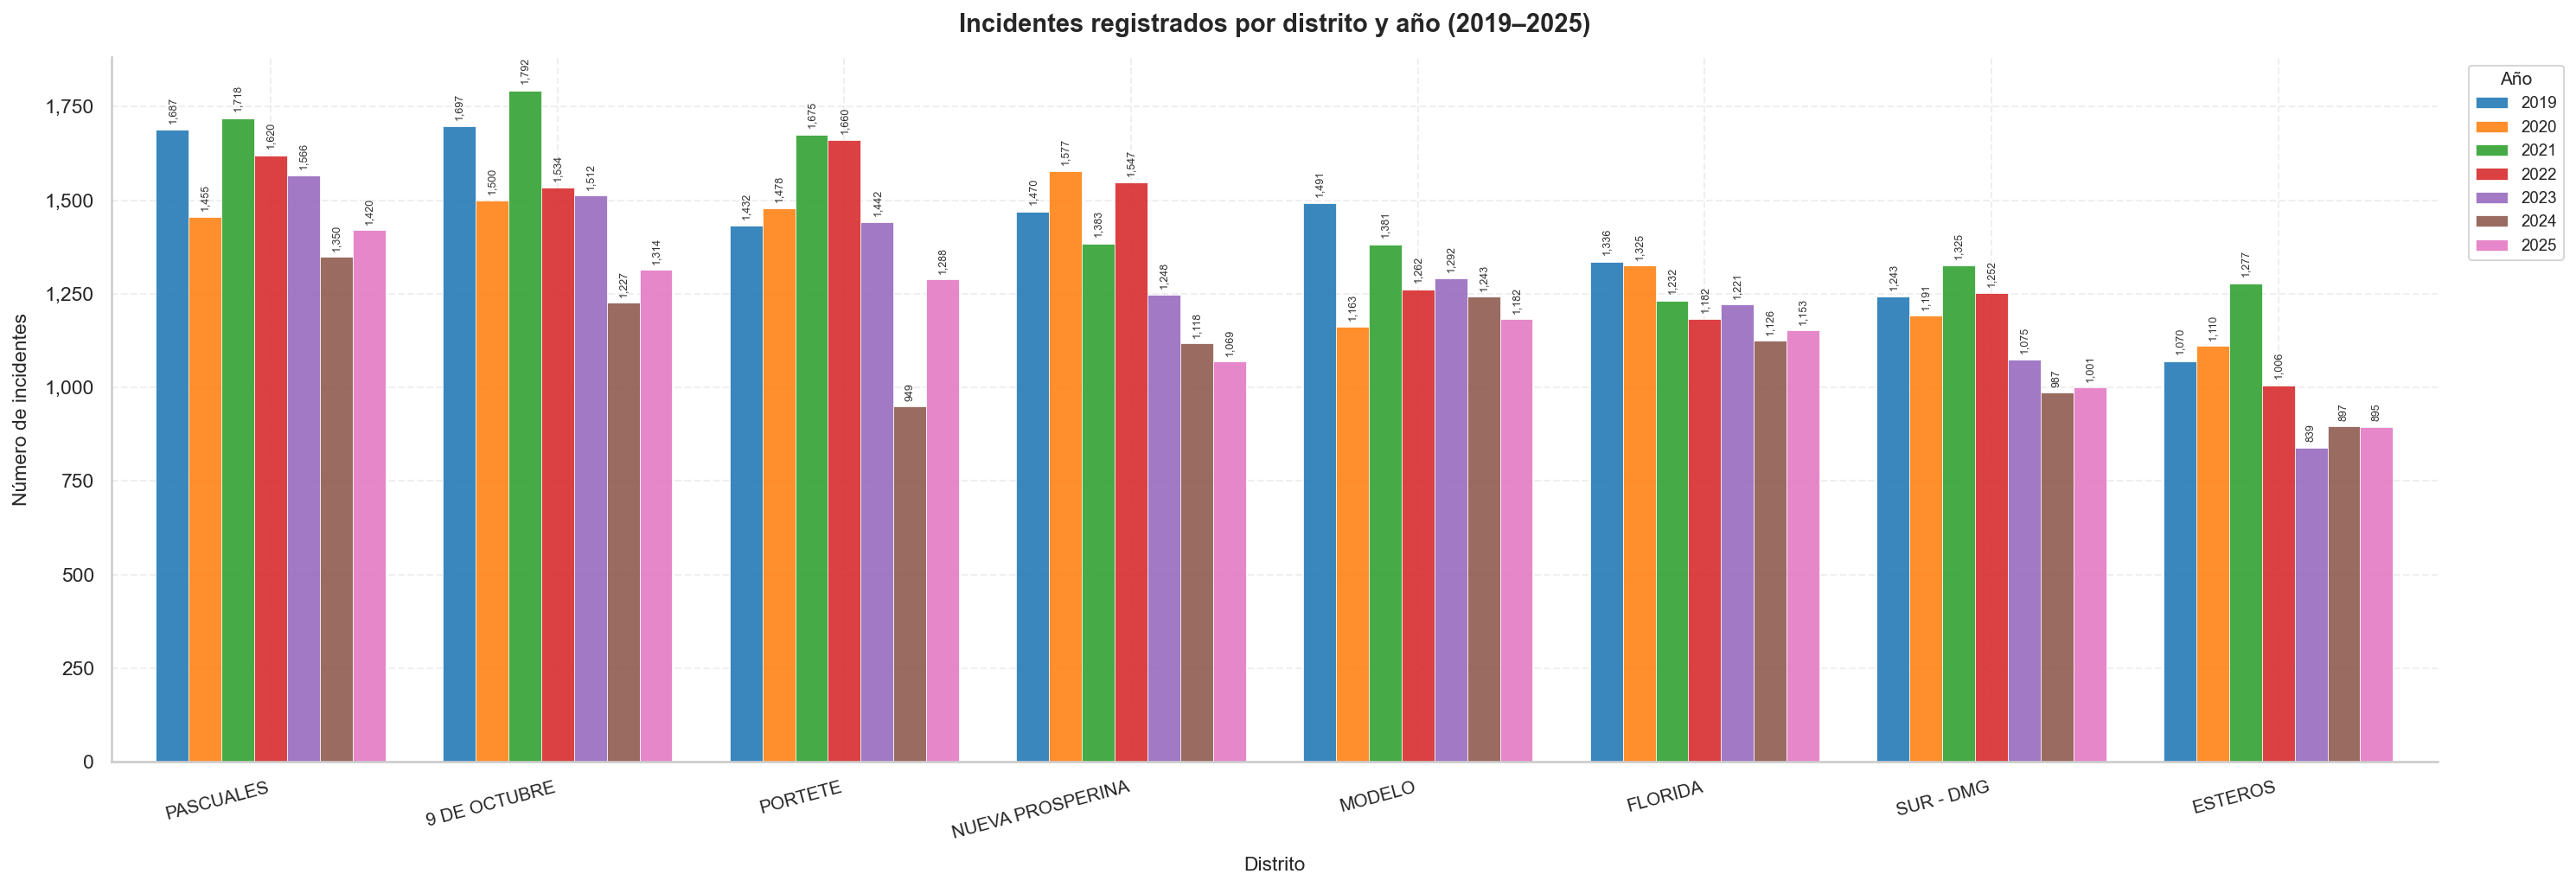

In [13]:
# =============================================================
# INCIDENTES POR DISTRITO Y AÑO (barras agrupadas)
# =============================================================
top8_distritos = (
    df.groupby('nombre_distrito')
    .size()
    .sort_values(ascending=False)
    .head(8)
    .index.tolist()
)

por_dist_anio = (
    df[df['nombre_distrito'].isin(top8_distritos)]
    .groupby(['anio','nombre_distrito'])
    .size()
    .reset_index(name='total')
)

pivot_dist = (
    por_dist_anio
    .pivot(index='nombre_distrito', columns='anio', values='total')
    .reindex(top8_distritos)
    [YEARS]
)

grafica_agrupada(
    pivot_dist,
    titulo       = 'Incidentes registrados por distrito y año (2019–2025)',
    xlabel       = 'Distrito',
    ylabel       = 'Número de incidentes',
    figsize      = (20, 7),
    rotation     = 15,
    fontsize_bar = 6,
)


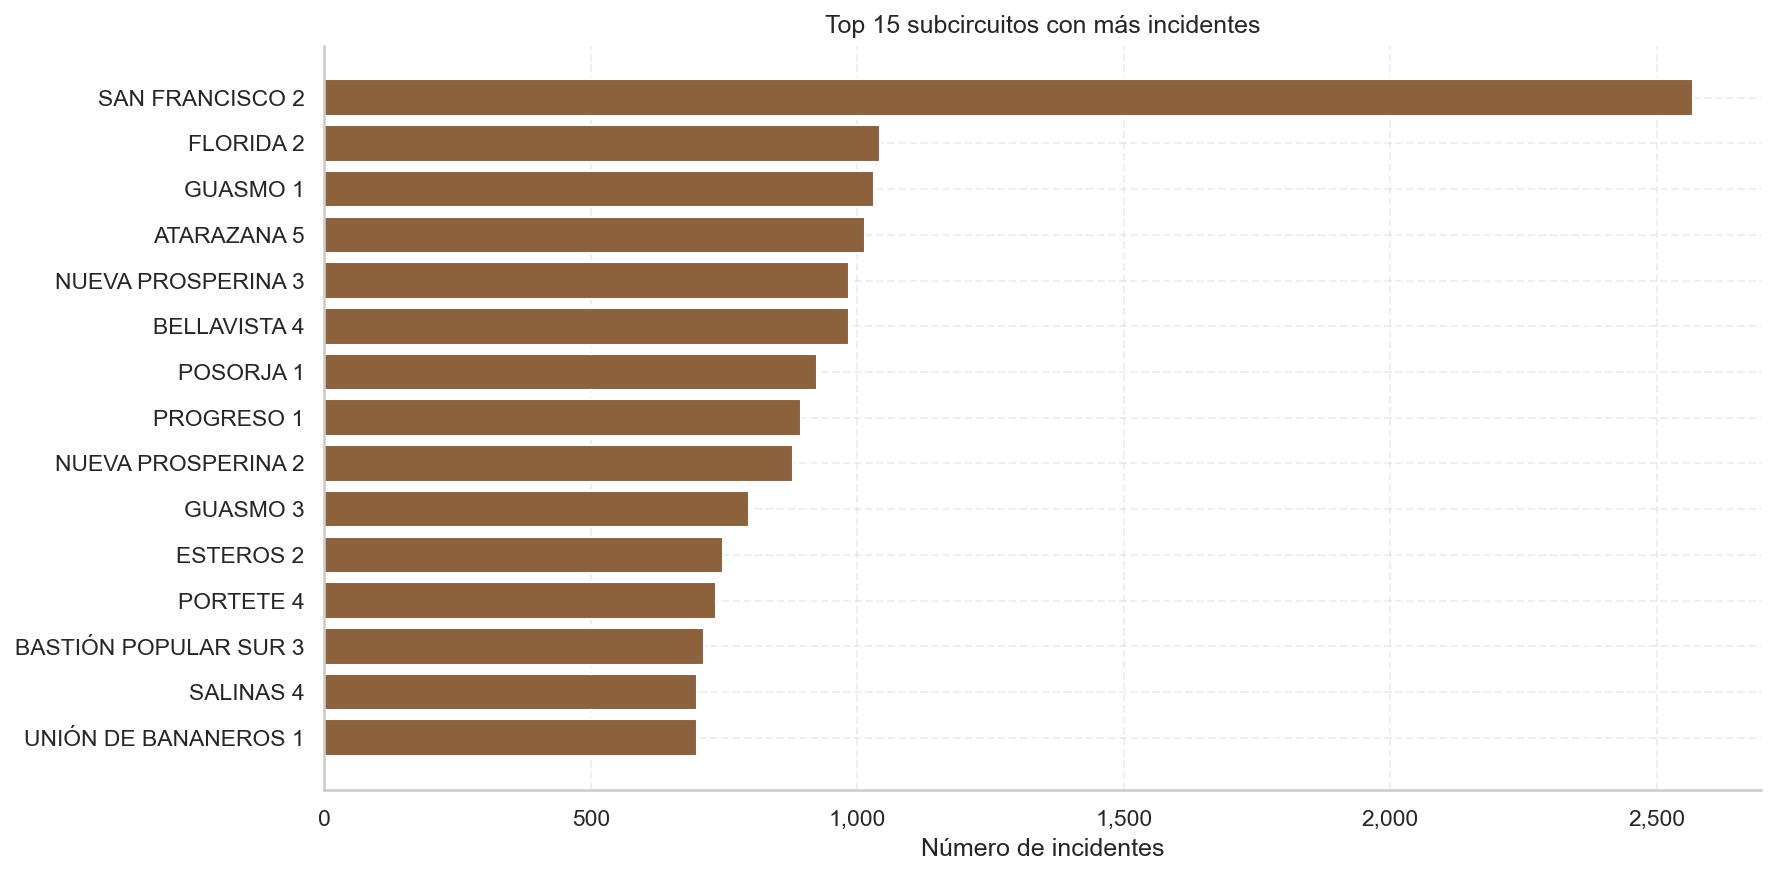

In [14]:
# =========================
# TOP 15 SUBCIRCUITOS CON MÁS INCIDENTES
# =========================
top_sub = (
    df.groupby(["codigo_subcircuito", "nombre_subcircuito"])
    .size()
    .reset_index(name="total")
    .sort_values("total", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_sub["nombre_subcircuito"][::-1], top_sub["total"][::-1],
        color=sns.color_palette("muted")[5])
ax.set_title("Top 15 subcircuitos con más incidentes")
ax.set_xlabel("Número de incidentes")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

## 5. Tipo de arma y lugar

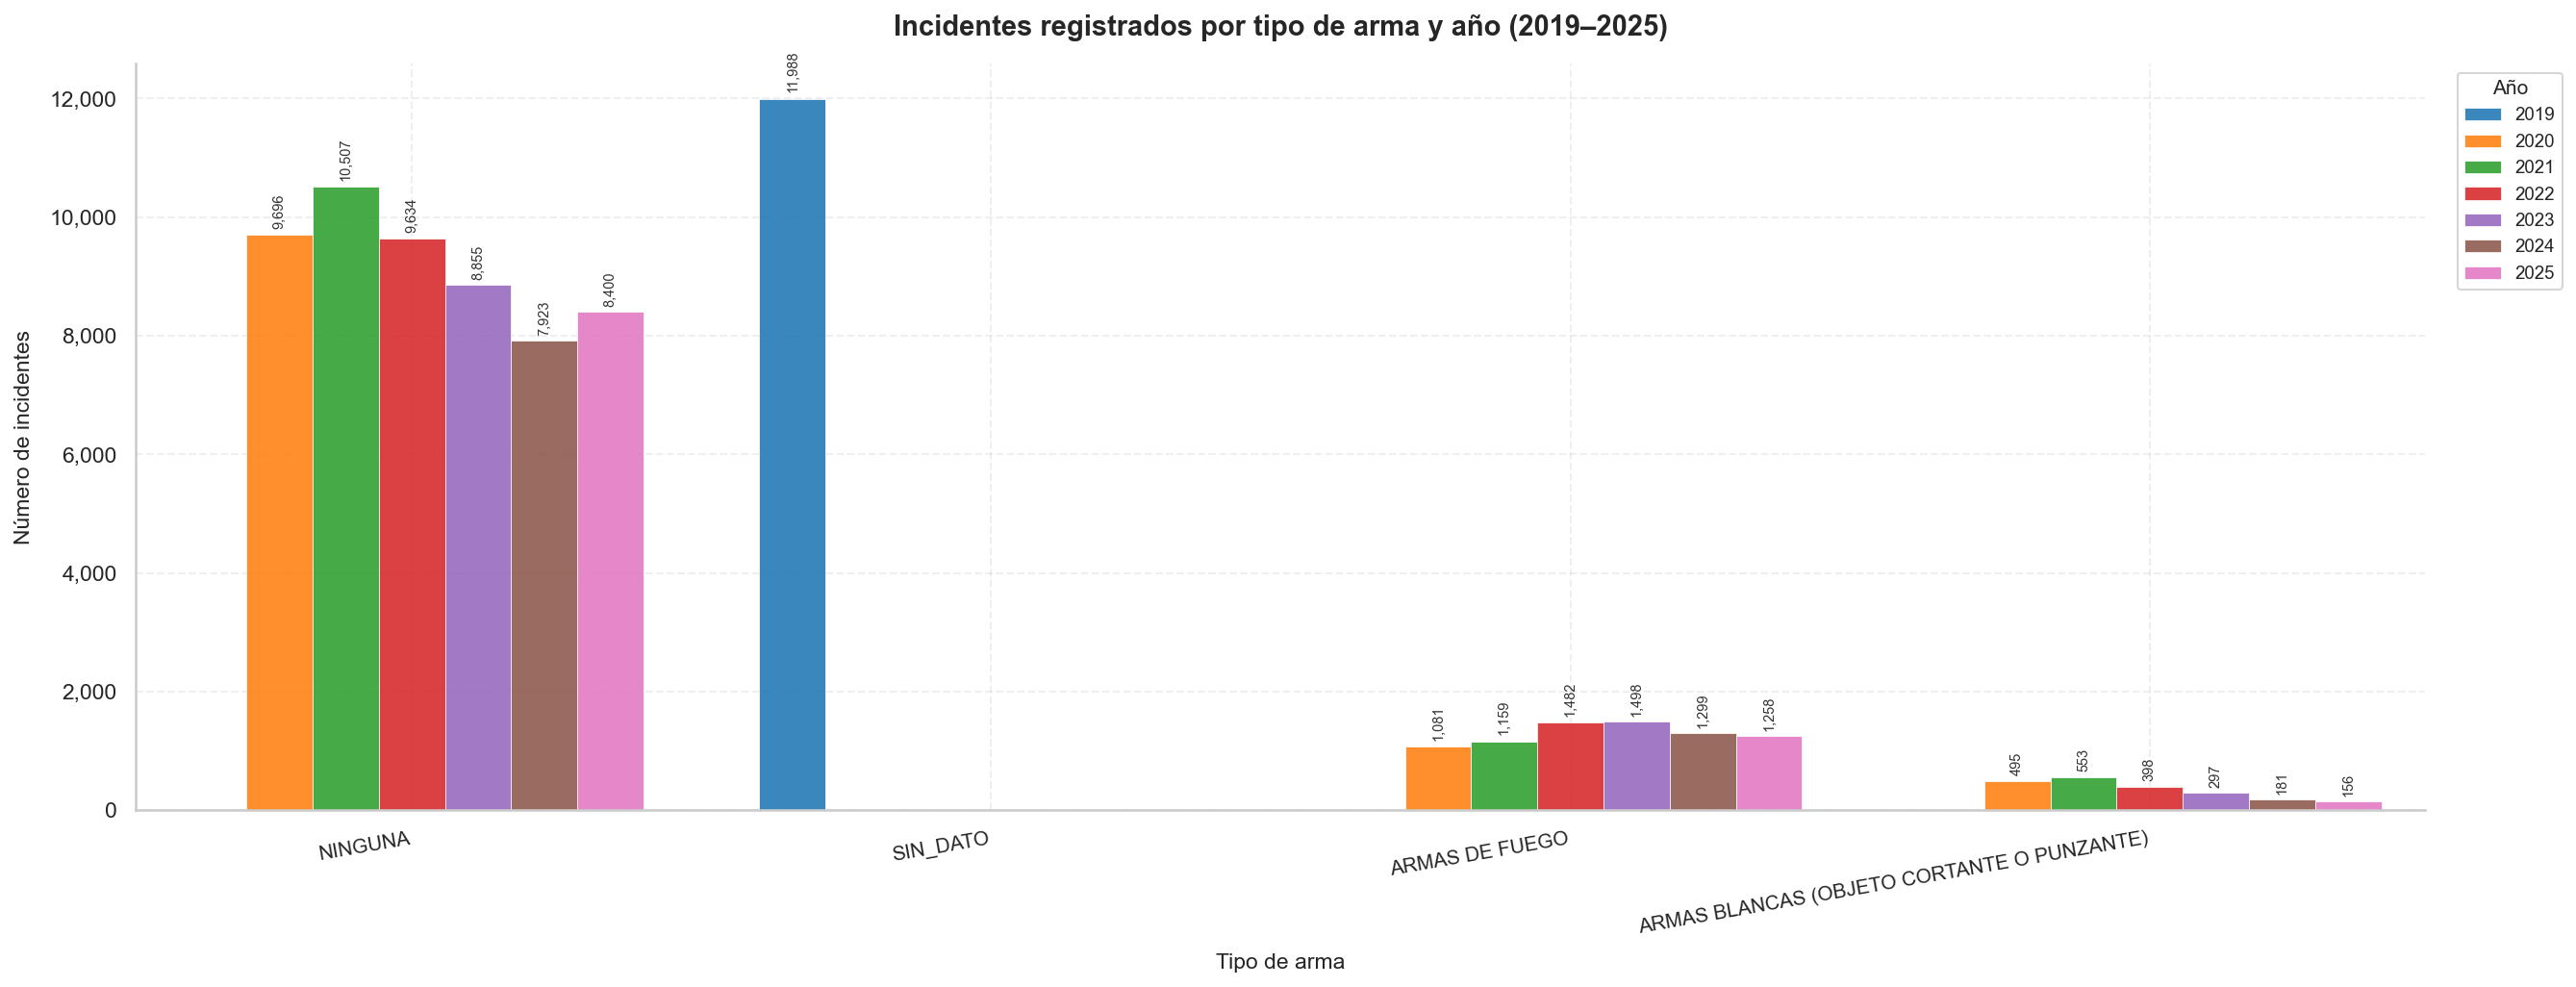

In [15]:
# =============================================================
# INCIDENTES POR TIPO DE ARMA Y AÑO (barras agrupadas)
# =============================================================
orden_armas = df['tipo_arma'].value_counts().index.tolist()

por_arma_anio = (
    df.groupby(['anio','tipo_arma'])
    .size()
    .reset_index(name='total')
)

pivot_arma = (
    por_arma_anio
    .pivot(index='tipo_arma', columns='anio', values='total')
    .reindex(orden_armas)
    [YEARS]
)

grafica_agrupada(
    pivot_arma,
    titulo       = 'Incidentes registrados por tipo de arma y año (2019–2025)',
    xlabel       = 'Tipo de arma',
    ylabel       = 'Número de incidentes',
    figsize      = (18, 7),
    rotation     = 10,
    fontsize_bar = 7,
)


In [20]:
# =========================
# DISTRIBUCIÓN POR TIPO DE LUGAR — TODAS LAS CATEGORÍAS
# =========================
por_lugar = df["tipo_lugar"].value_counts().reset_index()
por_lugar.columns = ["tipo_lugar", "total"]

# Alto dinámico: 0.4 pulgadas por categoría
alto = max(10, len(por_lugar) * 0.4)

print(por_lugar.to_string(index=False))

                                        tipo_lugar  total
                           ÁREAS DE ACCESO PÚBLICO  50350
                                      ÁREA PRIVADA  10761
                              VIVIENDA/ALOJAMIENTO   6513
                                       VÍA PÚBLICA   1828
                       ÁREAS DEDICADAS AL COMERCIO   1184
             CENTRO DE REHABILITACIÓN SOCIAL (CRS)   1107
                                        TRANSPORTE   1026
                                ENTIDADES PUBLICAS    634
                 UNIDADES DE REACCIÓN Y EMERGENCIA    495
                                   ESPACIO PÚBLICO    480
                          INSTITUCIONES EDUCATIVAS    408
                                   ESPACIO PRIVADO    328
                     LUGARES QUE PRESTAN SERVICIOS    301
CENTRO DE PRIVACIÓN PROVISIONAL DE LIBERTAD (CPPL)    273
                               VIVIENDA PARTICULAR    189
                            INSTITUCIONES DE SALUD    186
          CENT

## 6. Mapa de calor: hora vs. día de la semana

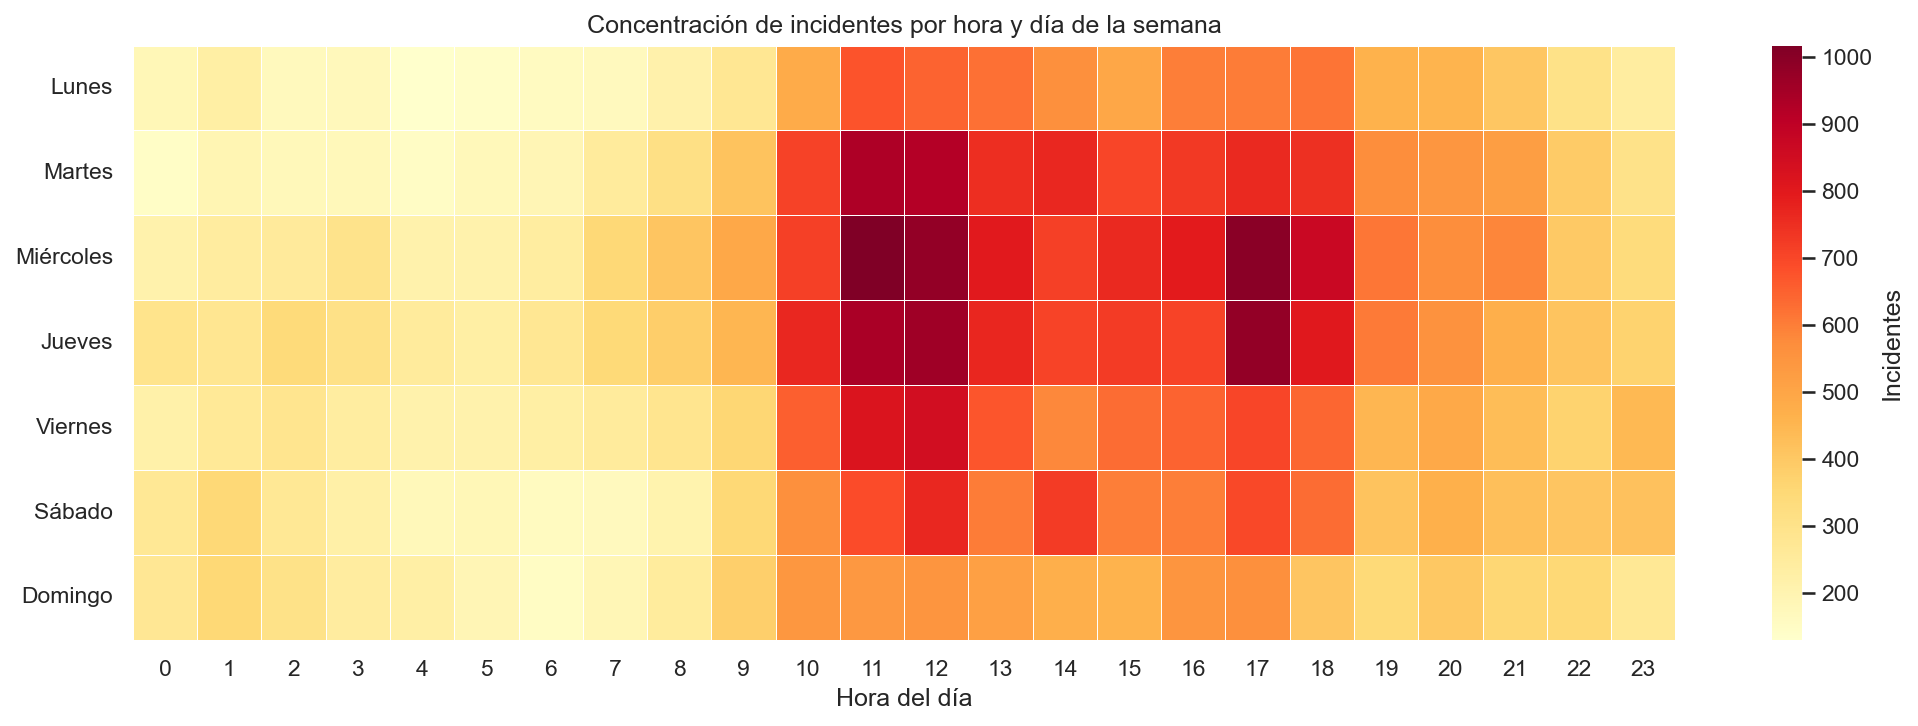

In [18]:
# =========================
# HEATMAP HORA x DÍA DE LA SEMANA
# Muestra en qué combinaciones hora-día ocurren más incidentes
# =========================
DIAS = ["Lunes","Martes","Miércoles","Jueves","Viernes","Sábado","Domingo"]

pivot = (
    df.groupby(["dia_semana", "hora"])
    .size()
    .unstack(fill_value=0)
)
pivot.index = DIAS

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    pivot, ax=ax, cmap="YlOrRd",
    linewidths=0.3, linecolor="white",
    cbar_kws={"label": "Incidentes"}
)
ax.set_title("Concentración de incidentes por hora y día de la semana")
ax.set_xlabel("Hora del día")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 7. Resumen estadístico

In [19]:
# =========================
# RESUMEN GENERAL
# =========================
print("=" * 50)
print("RESUMEN DEL DATASET MDI 2019–2025")
print("=" * 50)
print(f"Total de registros          : {len(df):,}")
print(f"Período                     : {df['anio'].min():.0f} – {df['anio'].max():.0f}")
print(f"Distritos                   : {df['codigo_distrito'].nunique()}")
print(f"Circuitos                   : {df['codigo_circuito'].nunique()}")
print(f"Subcircuitos                : {df['codigo_subcircuito'].nunique()}")
print(f"Tipos de delito únicos      : {df['delitos'].nunique()}")
print(f"Códigos ICCS únicos         : {df['codigo_iccs'].nunique()}")
print(f"Registros con coord real    : {(df['flag_coord']=='REAL').sum():,} ({(df['flag_coord']=='REAL').sum()/len(df)*100:.1f}%)")
print(f"Registros con coord imputada: {(df['flag_coord']=='IMPUTADO').sum():,} ({(df['flag_coord']=='IMPUTADO').sum()/len(df)*100:.1f}%)")
print(f"Registros ICCS original     : {(df['tipo_dato']=='ORIGINAL').sum():,} ({(df['tipo_dato']=='ORIGINAL').sum()/len(df)*100:.1f}%)")
print(f"Registros ICCS imputado     : {(df['tipo_dato']=='SINTETICO').sum():,} ({(df['tipo_dato']=='SINTETICO').sum()/len(df)*100:.1f}%)")
print()
print(f"Delito más frecuente        : {df['delitos'].value_counts().index[0]}")
print(f"Subcircuito con más casos   : {df['nombre_subcircuito'].value_counts().index[0]}")
print(f"Hora pico                   : {int(df['hora'].value_counts().index[0])}:00 h")
print(f"Día con más incidentes      : {DIAS[int(df['dia_semana'].value_counts().index[0])]}")

RESUMEN DEL DATASET MDI 2019–2025
Total de registros          : 76,860
Período                     : 2019 – 2025
Distritos                   : 10
Circuitos                   : 57
Subcircuitos                : 240
Tipos de delito únicos      : 45
Códigos ICCS únicos         : 180
Registros con coord real    : 9,814 (12.8%)
Registros con coord imputada: 67,046 (87.2%)
Registros ICCS original     : 56,045 (72.9%)
Registros ICCS imputado     : 20,815 (27.1%)

Delito más frecuente        : DELITOS POR LA PRODUCCIÓN O TRÁFICO ILÍCITO DE SUSTANCIAS CATALOGADAS SUJETAS A FISCALIZACIÓN
Subcircuito con más casos   : SAN FRANCISCO 2
Hora pico                   : 12:00 h
Día con más incidentes      : Miércoles
